# **Business news and US inflation: which topics matter and why?**
#### Based on the framework of Bybee, Kelly, Manela, & Xiu (2021)

**Authors:** Emma LEGUAY, Carla LUCAS

**Institution:** ENSAE Paris / IP Paris

This project explores the relationship between business news narratives and economic fluctuations. We analyze how latent topics extracted from business news track real-time economic activity.

While grounded in the original study's approach to real activity and asset prices, this notebook extends the analysis to investigate the predictive power of news attention on **U.S. Inflation dynamics (CPI & PCE)**.


### *Import*

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import warnings
from group_lasso import GroupLasso
from sklearn.model_selection import TimeSeriesSplit

import src.config as cfg
import src.utils as ut
import src.data_loader as dl
import src.var_irfs as irf
import src.group_lasso as gl

warnings.filterwarnings('ignore')
print(f"Environment loaded. Analysis period: {cfg.START_DATE} to {cfg.END_DATE}")

Environment loaded. Analysis period: 1984-01-01 to 2017-06-01


In [2]:
theta, labels_map = dl.load_topics('data')
print(f"Topics loaded: {theta.shape[1]} topics over {len(theta)} months.")

Topics loaded: 180 topics over 402 months.


### **News data and inflation : sparse topic regression**

##### *1. Configuration and data*

In [3]:
# ---- Load FRED data ----
cpi = dl.fred_download_csv(cfg.FRED_SERIES["CPIAUCSL"], cfg.FRED_START, cfg.FRED_END).rename(columns={"CPIAUCSL":"CPI"})
pce = dl.fred_download_csv(cfg.FRED_SERIES["PCEPI"], cfg.FRED_START, cfg.FRED_END).rename(columns={"PCEPI":"PCEPI"})

# Harmonise index en month-start
for d in (cpi, pce):
    d.index = d.index.to_period("M").to_timestamp(how="start") 

fred_m = pd.concat([cpi, pce], axis=1).dropna()
data = pd.DataFrame(index=fred_m.index)

data['CPI'] = np.log(fred_m['CPI']).diff() * 1200
data['PCEPI'] = np.log(fred_m['PCEPI']).diff() * 1200

data = data.dropna()

common = theta.index.intersection(data.index)
X = theta.loc[common]
Y = data.loc[common]

##### *2. Function*

In [4]:
def run_forecast_analysis(short_name, full_name, y_target, X_features):
    MIN_TRAIN_SIZE = 120
    
    # STANDARDIZATION 
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    
    X_std = pd.DataFrame(scaler_X.fit_transform(X_features), index=X_features.index, columns=X_features.columns)
    y_std = pd.Series(scaler_y.fit_transform(y_target.values.reshape(-1,1)).flatten(), index=y_target.index)
    
    # A. IN-SAMPLE ANALYSIS
    # Selection of top 5 variables
    top_5_vars = ut.select_exact_k_lars(X_std, y_std, k=cfg.N_VARS_LASSO)
    
    X_ols = sm.add_constant(X_std[top_5_vars])
    model = sm.OLS(y_std, X_ols).fit()
    r2_in = model.rsquared
    
    # B. OUT-OF-SAMPLE ANALYSIS
    trues_oos = []
    preds_oos = []
    hist_means = []
    
    for i in range(MIN_TRAIN_SIZE, len(y_std)):
        y_train = y_std.iloc[:i]
        X_train = X_std.iloc[:i]
        y_test_pt = y_std.iloc[i]
        X_test_row = X_std.iloc[[i]]
        
        # Selection of top 5 variables
        vars_t = ut.select_exact_k_lars(X_train, y_train, k=cfg.N_VARS_LASSO)
        
        # Fit & predict
        reg = LinearRegression().fit(X_train[vars_t], y_train)
        pred = reg.predict(X_test_row[vars_t])[0]
        
        preds_oos.append(pred)
        trues_oos.append(y_test_pt)
        hist_means.append(y_train.mean())

    # R2 OOS
    mse_model = np.mean((np.array(trues_oos) - np.array(preds_oos))**2)
    mse_bench = np.mean((np.array(trues_oos) - np.array(hist_means))**2)
    r2_out = 1 - (mse_model / mse_bench)
    
    # C. TABLES
    res = pd.DataFrame({
        'Coeff': model.params[top_5_vars], 
        'Pval': model.pvalues[top_5_vars]
    })
    res['Topic'] = [labels_map.get(str(v), v) if str(v) in labels_map else labels_map.get(v, v) for v in res.index]
    res = res.sort_values(by='Coeff', key=abs, ascending=False)
    
    print(f"\n{'-'*75}")
    print(f"TABLE : {full_name.upper()}")
    print(f"{'-'*75}")
    print(f"{'Topic':<35} | {'Coeff.':>7} | {'P-val':>8} | {'Sig'}")
    print(f"{'-'*75}")
    
    for _, row in res.iterrows():
        star = ut.get_stars(row['Pval'])
        print(f"{row['Topic']:<35} | {row['Coeff']:>7.2f} | {row['Pval']:>8.4f} | {star}")
        
    print(f"{'-'*75}")
    print(f"In-Sample R2     : {r2_in:.2f}")
    print(f"Out-of-Sample R2 : {r2_out:.2f}")
    print(f"{'-'*75}")
    
    # D. GRAPHS
    vars_final = ut.select_exact_k_lars(X_std, y_std, k=cfg.N_VARS_LASSO)
    reg_final = LinearRegression().fit(X_std[vars_final], y_std)
    preds_in_sample = reg_final.predict(X_std[vars_final])

    dates_oos = y_std.index[MIN_TRAIN_SIZE:] 
    preds_oos_aligned = pd.Series(preds_oos, index=dates_oos)

    plt.figure(figsize=(12, 5))
    plt.plot(y_std.index, y_std, 'k-', lw=1, alpha=0.3, label='Actual data')
    plt.plot(y_std.index, preds_in_sample, 'b--', lw=1, alpha=0.8, label='In-sample fit (explain)')
    plt.plot(dates_oos, preds_oos_aligned, 'r-', lw=1.5, label='Out-of-sample forecast')
    
    plt.axvline(y_std.index[MIN_TRAIN_SIZE], color='gray', linestyle=':', label='OOS start')
    plt.title(f"{full_name}: Topic model performance")
    plt.legend()
    plt.tight_layout()
    
    plt.show()

##### *3. Execution*


---------------------------------------------------------------------------
TABLE : CPI INFLATION
---------------------------------------------------------------------------
Topic                               |  Coeff. |    P-val | Sig
---------------------------------------------------------------------------
Recession                           |   -0.23 |   0.0000 | ***
Germany                             |    0.13 |   0.0080 | ***
Publishing                          |    0.10 |   0.0466 | **
European sovereign debt             |   -0.10 |   0.0869 | *
Macroeconomic data                  |    0.05 |   0.3828 | 
---------------------------------------------------------------------------
In-Sample R2     : 0.16
Out-of-Sample R2 : 0.04
---------------------------------------------------------------------------


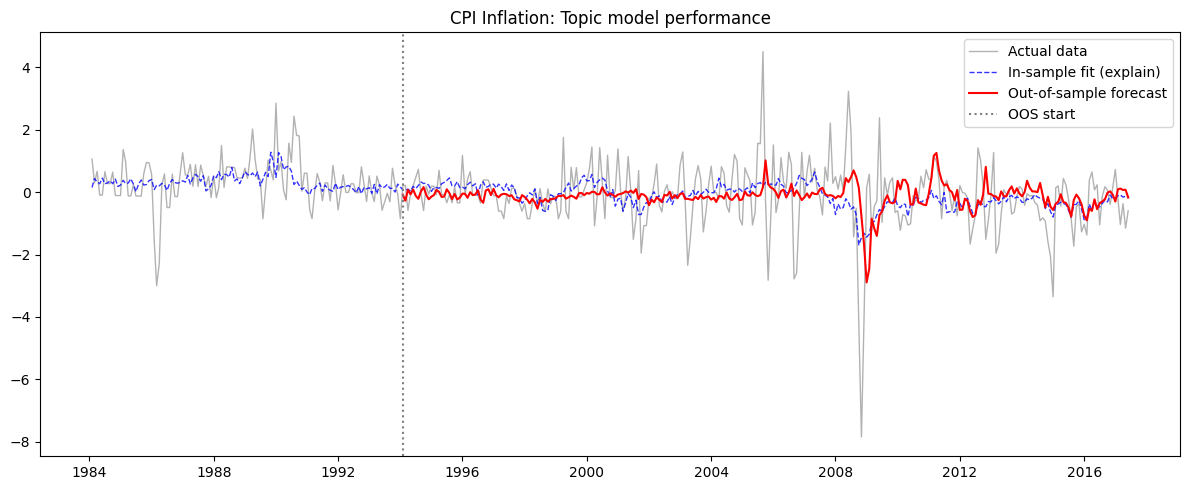


---------------------------------------------------------------------------
TABLE : PCE INFLATION
---------------------------------------------------------------------------
Topic                               |  Coeff. |    P-val | Sig
---------------------------------------------------------------------------
Recession                           |   -0.26 |   0.0000 | ***
Small changes                       |    0.12 |   0.0245 | **
Aerospace/defense                   |    0.08 |   0.1705 | 
European sovereign debt             |   -0.08 |   0.1732 | 
Macroeconomic data                  |    0.07 |   0.2540 | 
---------------------------------------------------------------------------
In-Sample R2     : 0.19
Out-of-Sample R2 : 0.13
---------------------------------------------------------------------------


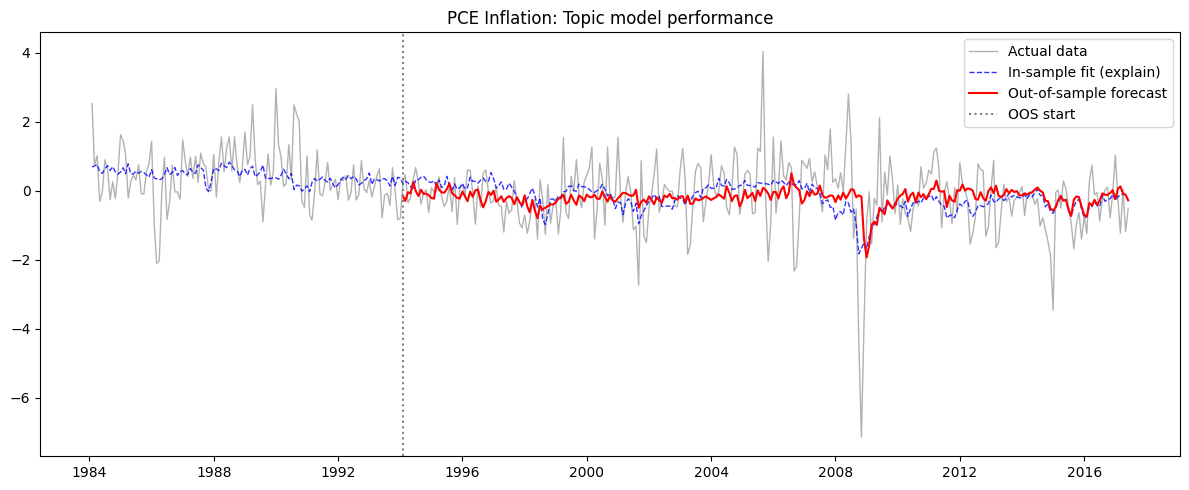

In [5]:
NAME_MAPPING = {'CPI': 'CPI Inflation', 'PCEPI': 'PCE Inflation'}
for short_col, full_name in NAME_MAPPING.items():
    if short_col in Y.columns:
        run_forecast_analysis(short_col, full_name, Y[short_col], X)

### **News data and inflation : Group-Lasso VAR selection** on PCE inflation

##### *1. Loading data*

In [6]:
print("[1/5] Loading theta topics ...")
theta = dl.load_theta(cfg.THETA_FILE)  # index month-start
topic_cols = list(theta.columns)

print("[2/5] Downloading FRED series (INDPRO, FEDFUNDS, PCEPI) ...")
indpro = dl.fred_download_csv(cfg.FRED_SERIES["INDPRO"], cfg.FRED_START, cfg.FRED_END).rename(columns={"INDPRO":"INDPRO"})
ffr    = dl.fred_download_csv(cfg.FRED_SERIES["FEDFUNDS"], cfg.FRED_START, cfg.FRED_END).rename(columns={"FEDFUNDS":"FFR"})
pcepi  = dl.fred_download_csv(cfg.FRED_SERIES["PCEPI"], cfg.FRED_START, cfg.FRED_END).rename(columns={"PCEPI":"PCEPI"})

# Harmonise index en month-start
for d in (indpro, ffr, pcepi):
    d.index = d.index.to_period("M").to_timestamp(how="start")

print("[3/5] Downloading SP500 daily from Stooq + convert to monthly last ...")
sp500_daily = dl.stooq_download_spx_daily(cfg.FRED_START, cfg.FRED_END)   
sp500_m = dl.to_monthly(sp500_daily, how="last")
sp500_m.index = sp500_m.index.to_period("M").to_timestamp(how="start")

# ----- Transformations -----
# logIP_t et logSP500_t (comme dans ton script: 100*log(level))
df_macro = pd.concat([indpro["INDPRO"], ffr["FFR"], pcepi["PCEPI"], sp500_m["SP500"]], axis=1).sort_index()

df_macro["logIP"]    = 100.0 * dl.safe_log(df_macro["INDPRO"])
df_macro["logSP500"] = 100.0 * dl.safe_log(df_macro["SP500"])

# inflation PCE headline: pi_t = 1200 * log(P_t/P_{t-1})
df_macro["pi_pce"] = 1200.0 * (dl.safe_log(df_macro["PCEPI"]) - dl.safe_log(df_macro["PCEPI"].shift(1)))
# keep only y vars in requested order
y_raw = df_macro[["pi_pce", "logIP", "FFR", "logSP500"]].loc[cfg.FRED_START:cfg.FRED_END].dropna()

print("y_raw head:")
display(y_raw.head())

print("[4/5] Optional: load EPU, VIX/VXO, UMCSENT (comme 5.3 du papier) ...")
# EPU
epu = dl.load_epu_xlsx(cfg.EPU_XLSX_FILE).rename("EPU")
epu = epu.reindex(y_raw.index)

# VIX complété par VXO avant 1990 (même logique que ton script)
vix_daily = dl.fred_download_csv(cfg.FRED_SERIES["VIXCLS"], cfg.FRED_START, cfg.FRED_END)
vix_m = dl.to_monthly(vix_daily, how="last").rename(columns={"VIXCLS":"VIX"})
vix_m.index = vix_m.index.to_period("M").to_timestamp(how="start")

vxo_daily = dl.fred_download_csv(cfg.FRED_SERIES["VXOCLS"], cfg.FRED_START, cfg.FRED_END)
vxo_m = dl.to_monthly(vxo_daily, how="last").rename(columns={"VXOCLS":"VIX"})
vxo_m.index = vxo_m.index.to_period("M").to_timestamp(how="start")

cut = vix_m.index.min()
vix_full = pd.concat([vxo_m.loc[vxo_m.index < cut], vix_m]).sort_index()

# UMCSENT
umcs = dl.fred_download_csv(cfg.FRED_SERIES["UMCSENT"], cfg.FRED_START, cfg.FRED_END).rename(columns={"UMCSENT":"UMCSENT"})
umcs.index = umcs.index.to_period("M").to_timestamp(how="start")

print("[5/5] Build x_all = topics + (EPU, VIX, UMCSENT) ...")
x_topics = 100.0 * theta.copy()               # en %
x_all = pd.concat([x_topics, epu, vix_full["VIX"], umcs["UMCSENT"]], axis=1).dropna()

# Align y/x et impose start pour GL-VAR
joint = pd.concat([y_raw, x_all], axis=1).dropna()
joint = joint.loc[cfg.VAR_GL_START:]
y_all = joint[cfg.Y_ORDER]
x_all = joint[x_all.columns]

print("Aligned sample:")
print("  y_all:", y_all.shape, y_all.index.min(), "->", y_all.index.max())
print("  x_all:", x_all.shape, x_all.index.min(), "->", x_all.index.max())


[1/5] Loading theta topics ...
[2/5] Downloading FRED series (INDPRO, FEDFUNDS, PCEPI) ...
[3/5] Downloading SP500 daily from Stooq + convert to monthly last ...
y_raw head:


,pi_pce,logIP,FFR,logSP500
1984-02-01,8.046296,397.653278,9.59,505.662790
1984-03-01,3.928072,398.141660,9.91,507.003564
1984-04-01,4.562411,398.731599,10.29,507.548627
1984-05-01,1.516957,399.272888,10.32,501.429525
1984-06-01,2.135409,399.638989,11.06,503.161370


[4/5] Optional: load EPU, VIX/VXO, UMCSENT (comme 5.3 du papier) ...
[5/5] Build x_all = topics + (EPU, VIX, UMCSENT) ...
Aligned sample:
  y_all: (378, 4) 1986-01-01 00:00:00 -> 2017-06-01 00:00:00
  x_all: (378, 183) 1986-01-01 00:00:00 -> 2017-06-01 00:00:00


##### *2. Building and running Group-Lasso VAR*

[1/3] Variance-standardize y and x ...
[2/3] Build design matrix for VARX with grouped x-lags ...
  - Lags L=3
  - Samples (T-L)=375
  - #eq K=4  (should be 4)
  - #x vars M=183
  - #regressors P=562 = 1 + L*(K+M)
[3/3] Fit lambda path (Group-Lasso) + compute group norms ...
[0.2        0.19191446 0.18415579 0.17671079 0.16956678 0.16271158
 0.15613352 0.1498214  0.14376446 0.13795239 0.13237529 0.12702366
 0.12188838 0.11696071 0.11223225 0.10769496 0.1033411  0.09916325
 0.09515431 0.09130744 0.08761608 0.08407397 0.08067505 0.07741354
 0.07428388 0.07128076 0.06839904 0.06563382 0.06298039 0.06043424
 0.05799102 0.05564658 0.05339691 0.0512382  0.04916675 0.04717905
 0.04527171 0.04344148 0.04168524 0.04      ]
Lambda high (>=10 survivors): 0.0533969 | survivors: 10
Top10 survivors: ['Mexico', 'Tobacco', 'Unions', 'Earnings', 'Financial crisis', 'Germany', 'VIX', 'Southeast Asia', 'Indictments', 'Natural disasters']


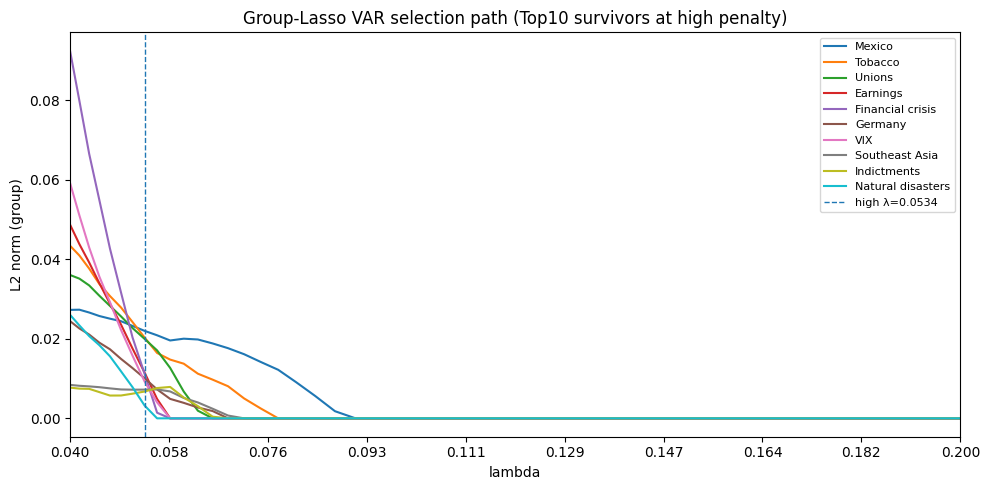

Saved: outputs/Figure9_like_Top10_L2norms_vs_lambda.png


In [7]:
print("[1/3] Variance-standardize y and x ...")
y_std = gl.variance_standardize(y_all)
x_std = gl.variance_standardize(x_all)

print("[2/3] Build design matrix for VARX with grouped x-lags ...")
Xmat, Ymat, groups, colmeta = gl.build_group_lasso_var_design(y=y_std, x=x_std, lags=cfg.LAGS)
x_vars = list(x_std.columns)
y_vars = list(y_std.columns)
n_groups = int(groups.max()) + 1

print(f"  - Lags L={cfg.LAGS}")
print(f"  - Samples (T-L)={Xmat.shape[0]}")
print(f"  - #eq K={Ymat.shape[1]}  (should be 4)")
print(f"  - #x vars M={len(x_vars)}")
print(f"  - #regressors P={Xmat.shape[1]} = 1 + L*(K+M)")

print("[3/3] Fit lambda path (Group-Lasso) + compute group norms ...")
norms_path = []

print(cfg.LAM_GRID_SCALED)

for lam_scaled in cfg.LAM_GRID_SCALED:
    lam_raw = float(lam_scaled)   # IMPORTANT: pas de *n (comme ta dernière version)

    group_reg = np.full(n_groups, lam_raw, dtype=float)
    group_reg[0] = 0.0  # const + y-lags non pénalisés

    grouplasso = GroupLasso(
                    groups=groups,
                    group_reg=group_reg,
                    l1_reg=0.0,
                    n_iter=cfg.N_ITER_PATH,
                    tol=cfg.TOL_PATH,
                    supress_warning=True,
                    fit_intercept=False,
                    scale_reg="none",
                    warm_start=True,
    )
    grouplasso.fit(Xmat, Ymat)
    coef = grouplasso.coef_.copy()

    norms = gl.group_l2_norms_by_var(coef, colmeta, x_vars)
    norms.name = float(lam_scaled)
    norms_path.append(norms)

norms_df = pd.DataFrame(norms_path).sort_index()
norms_df.index.name = "lambda"
norms_df.to_csv(cfg.OUT_DIR / "Figure9_norms_path_all_predictors.csv")

# ---- Top-10 survivors à haute pénalisation ----
def active_mask_row(row: pd.Series) -> pd.Series:
    thr = max(cfg.ABS_EPS, cfg.REL_EPS * float(row.max()))
    return row > thr

active_counts = norms_df.apply(lambda r: active_mask_row(r).sum(), axis=1)

if (active_counts >= 10).any():
    lam_high = float(active_counts[active_counts >= 10].index.max())
else:
    lam_high = float(norms_df.index.max())

top10 = norms_df.loc[lam_high].sort_values(ascending=False).head(10).index.tolist()
pd.Series(top10, name="top10_survivors").to_csv(cfg.OUT_DIR / "Figure9_top10_survivors.csv", index=False)

print(f"Lambda high (>=10 survivors): {lam_high:.6g} | survivors: {int(active_counts.loc[lam_high])}")
print("Top10 survivors:", top10)

# ---- Plot Figure 9-like (Top10 norms vs lambda) ----
plt.figure(figsize=(10, 5))
for v in top10:
    plt.plot(norms_df.index.values, norms_df[v].values, label=v)

plt.xlim(cfg.LAM_LO, cfg.LAM_HI)
xticks = np.linspace(cfg.LAM_LO, cfg.LAM_HI, 10)
plt.xticks(xticks, [f"{x:.3f}" for x in xticks])
plt.axvline(lam_high, linestyle="--", linewidth=1, label=f"high λ={lam_high:.4g}")
plt.xlabel("lambda")
plt.ylabel("L2 norm (group)")
plt.title("Group-Lasso VAR selection path (Top10 survivors at high penalty)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(cfg.OUT_DIR / "Figure9_like_Top10_L2norms_vs_lambda.png", dpi=200)
plt.show()
plt.close()

print("Saved:", cfg.OUT_DIR / "Figure9_like_Top10_L2norms_vs_lambda.png")

In [8]:
from pathlib import Path
import pandas as pd
import difflib

DATA_DIR = Path("data")
PHI_FILE = DATA_DIR / "phi_scaled.csv"
topics_wanted = ["Mexico", "Tobacco", "Unions", "Earnings", "Financial crisis"]
TOPN = 10

phi_raw = pd.read_csv(PHI_FILE)

# Détecte la colonne qui contient le texte du terme (souvent 1ère colonne)
term_col_candidates = [c for c in phi_raw.columns if c.lower() in ("term", "word", "token", "vocab")]
term_col = term_col_candidates[0] if term_col_candidates else phi_raw.columns[0]

# Met le terme TEXTE en index (pas un numéro), puis conversion des poids en numériques
phi = phi_raw.rename(columns={term_col: "term"}).set_index("term")
phi = phi.apply(pd.to_numeric, errors="coerce")

def closest_topic(name: str, cols, k=5):
    return difflib.get_close_matches(name, list(cols), n=k, cutoff=0.4)

rows = []
for topic in topics_wanted:
    if topic not in phi.columns:
        close = closest_topic(topic, phi.columns)
        print(f"[WARN] Topic '{topic}' introuvable. Exemples proches: {close}")
        continue

    s = phi[topic].dropna().sort_values(ascending=False).head(TOPN)

    out = pd.DataFrame(
        {
            "topic": topic,
            "rank": range(1, len(s) + 1),
            "term": s.index.astype(str),     # <-- le terme lui-même
            "weight": s.values,
        }
    )
    rows.append(out)

topwords_df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
display(topwords_df)

# Optionnel: sauvegarde
topwords_df.to_csv(cfg.OUT_DIR / "top10_terms_phi_selected_topics.csv", index=False)
print("Saved:", cfg.OUT_DIR / "top10_terms_phi_selected_topics.csv")


,topic,rank,term,weight
0,Mexico,1,mexican,232.036504
1,Mexico,2,salinas,229.918953
2,Mexico,3,mexican government,228.902973
3,Mexico,4,grupo,213.763751
4,Mexico,5,mexico,209.718135
5,Mexico,6,mexico city,193.972319
6,Mexico,7,ernesto,179.445268
7,Mexico,8,lopez,178.181578
8,Mexico,9,mexican peso,159.185600
9,Mexico,10,telefonos,152.118240


Saved: outputs/top10_terms_phi_selected_topics.csv


The topics that arise make economic sense, especially "Tobacco", "Unions", "Earnings", and "Financial crisis", when one knows the underlying words behind those topics. Indeed, **"Tobacco"** is a type of product that has seen in the past 20 years a strong increase of its price, as a result of public policies aiming at discouraging young people to start smoking, and to decrease tobacco demand. The topic **"Unions"** also makes very much economic sense. Indeed, they represent the workers and build their market power in the wages negotiation process. Although unions have lost a lot of members and hence of power recently, they still play an important role in the increase of wages, which play an extremely important role in the overall inflation. **"Earnings"** also make sense: it is not the sales of firms, but what the firms are able to benefit from their activity (in a microeconomic setting it woudl approximately be the difference between the price minus the unit cost times the level of production). It is related to this idea of mark-ups that firms are trying to reach on top of their unit costs. If the firms maintain their mark-ups although their costs increase, it means that their are conveying their cost-push inflationary shocks to their prices, hence increasing inflation. Finally **"Financial crisis"** is also clearly related with inflation.

However, what might be more difficult to understand is this importance of the topic "Mexico". Within the words of this topic, only the word "mexican peso", which is the currency of the country, seems to be related with a vague idea of prices/inflation. This points to the need to refine our methodology in several ways, on top of allowing the algorithm to converge better by using more iterations, more restrictive tolerance threshold, etc. But this would be forgetting that Mexico is a very important country in terms of imports and exports for the US : with Germany and South East Asian countries, like China, or with Canada, Mexico represent one of the biggest import share of the trade flows in the direction of the US. We think that this topic, with the other geographic mentions arising in the top10 topics, represent this idea of "imported inflation".

#### *3. Cross validation*

CV RMSE vs lambda ...
lambda_opt = 0.084074 | min RMSE = 0.47177


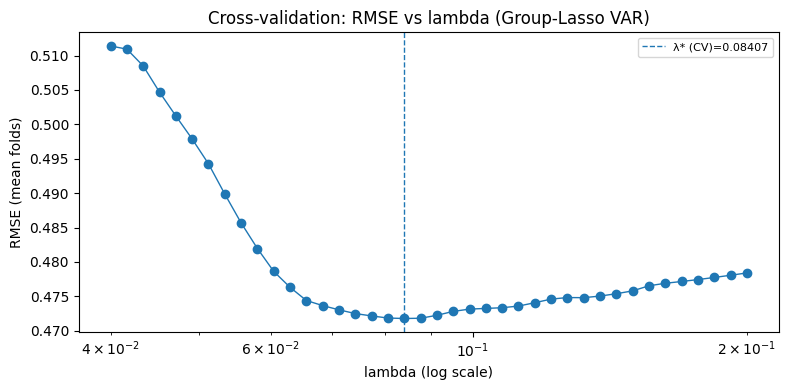

Saved: outputs/Figure9_CV_RMSE_vs_lambda.png


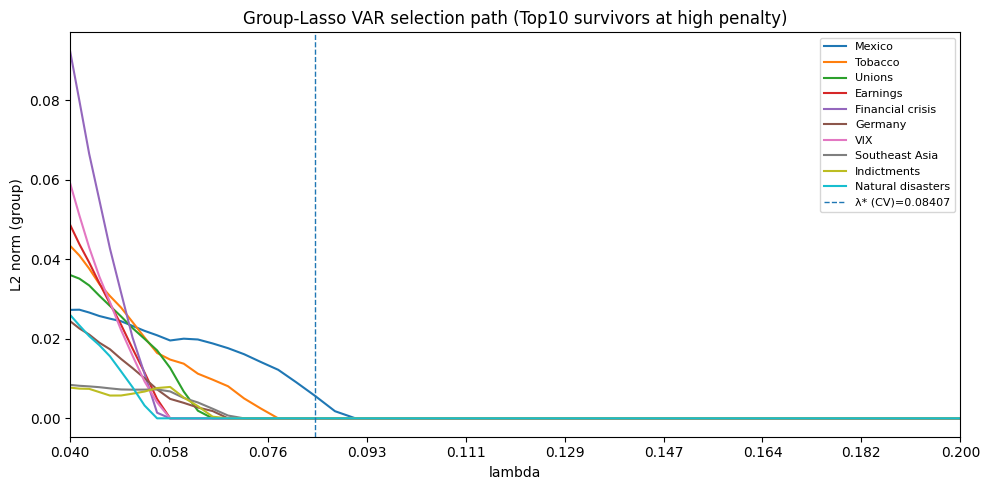

Saved: outputs/Figure9_like_Top10_L2norms_vs_lambda.png


In [9]:
print("CV RMSE vs lambda ...")
lam_grid = np.array(sorted([float(x) for x in cfg.LAM_GRID_SCALED]))  # ascending for plotting
tscv = TimeSeriesSplit(n_splits=cfg.CV_SPLITS)

rmse_means, rmse_stds = [], []

for lam in lam_grid:
    group_reg = np.full(n_groups, float(lam), dtype=float)
    group_reg[0] = 0.0  # const + y-lags non pénalisés

    fold_rmses = []
    for tr, te in tscv.split(Xmat):
        grouplasso = GroupLasso(
            groups=groups,
            group_reg=group_reg,
            l1_reg=0.0,
            n_iter=cfg.N_ITER_CV,
            tol=cfg.TOL_CV,
            supress_warning=True,
            fit_intercept=False,
            scale_reg="none",
            warm_start=False,
        )
        grouplasso.fit(Xmat[tr], Ymat[tr])
        pred = grouplasso.predict(Xmat[te])

        mse = np.mean((Ymat[te] - pred) ** 2)
        fold_rmses.append(float(np.sqrt(mse)))

    rmse_means.append(float(np.mean(fold_rmses)))
    rmse_stds.append(float(np.std(fold_rmses, ddof=1)) if len(fold_rmses) > 1 else 0.0)

rmse_cv = pd.DataFrame({"lambda": lam_grid, "rmse_mean": rmse_means, "rmse_std": rmse_stds}).set_index("lambda")
rmse_cv.to_csv(cfg.OUT_DIR / "Figure9_CV_RMSE_vs_lambda.csv")

lam_opt = float(rmse_cv["rmse_mean"].idxmin())
print(f"lambda_opt = {lam_opt:.6g} | min RMSE = {rmse_cv.loc[lam_opt,'rmse_mean']:.6g}")

# Plot RMSE curve
plt.figure(figsize=(8, 4))
plt.plot(rmse_cv.index.values, rmse_cv["rmse_mean"].values, marker="o", linewidth=1)
plt.axvline(lam_opt, linestyle="--", linewidth=1, label=f"λ* (CV)={lam_opt:.4g}")
plt.xscale("log")
plt.xlabel("lambda (log scale)")
plt.ylabel("RMSE (mean folds)")
plt.title("Cross-validation: RMSE vs lambda (Group-Lasso VAR)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(cfg.OUT_DIR / "Figure9_CV_RMSE_vs_lambda.png", dpi=200)
plt.show()
plt.close()

print("Saved:", cfg.OUT_DIR / "Figure9_CV_RMSE_vs_lambda.png")

plt.figure(figsize=(10, 5))
for v in top10:
    plt.plot(norms_df.index.values, norms_df[v].values, label=v)

plt.xlim(cfg.LAM_LO, cfg.LAM_HI)
xticks = np.linspace(cfg.LAM_LO, cfg.LAM_HI, 10)
plt.xticks(xticks, [f"{x:.3f}" for x in xticks])
plt.axvline(lam_opt, linestyle="--", linewidth=1, label=f"λ* (CV)={lam_opt:.4g}")
plt.xlabel("lambda")
plt.ylabel("L2 norm (group)")
plt.title("Group-Lasso VAR selection path (Top10 survivors at high penalty)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(cfg.OUT_DIR / "Figure9_like_Top10_L2norms_vs_lambda.png", dpi=200)
plt.show()
plt.close()

print("Saved:", cfg.OUT_DIR / "Figure9_like_Top10_L2norms_vs_lambda.png")

What is really interesting to see here is that, like in the work by Bybee et al. (2021), at the optimal lambda, only one regressor is kept, which is the last remaining topic news attention variable for very high level of penalty. It means that in order to improve inflation forecasting on top of traditional macroeconomic data, one doesn't need more than one topic attention in the news, at the condition that one is able to identify the right topic, depending on the macroeconomic variable of interest (here inflation, different in the case of economic activity)

However, this selection of the only topic in the news that we are not able to really link with inflation is problematic.

### **News attention shock vs SP500 shock, impact on inflation**

In [10]:
topic_star = "Mexico"

[1/2] Build VAR dataset and run IRFs (inflation response to both shocks) NEWS FIRST ...
  - shock_news: shock=news_attn_star | T=401


  - shock_sp500: shock=logSP500 | T=401


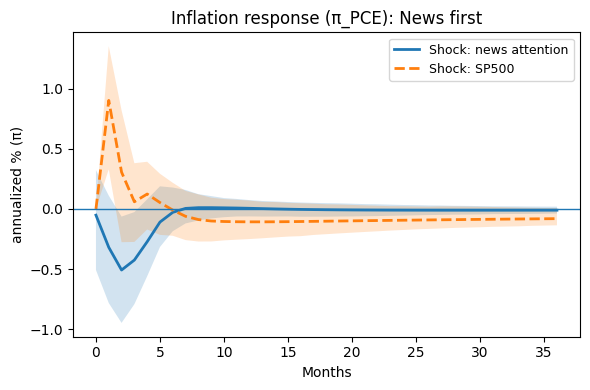

Saved: outputs/IRF_inflation_news_Mexico_1stvs_sp500.png


In [11]:
print("[1/2] Build VAR dataset and run IRFs (inflation response to both shocks) NEWS FIRST ...")

topic_star_attn = (100.0 * theta[topic_star]).rename("news_attn_star")
topic_star_attn = topic_star_attn.reindex(y_raw.index)

# Dataset VAR : ordering = news first + y_t demandé
df_var = pd.concat(
    [topic_star_attn, y_raw], axis=1
).dropna()

ordering = ["news_attn_star"] + cfg.Y_ORDER  # news first + (pi, logIP, FFR, logSP500)

# Run 2 IRFs: shock news vs shock SP500, même ordering
specs_inf = {
    "shock_news":  {"df": df_var, "ordering": ordering, "shock": "news_attn_star", "label": "News-attn shock"},
    "shock_sp500": {"df": df_var, "ordering": ordering, "shock": "logSP500",      "label": "SP500 shock"},
}

results_inf = {}

for key, s in specs_inf.items():
    df_use = s["df"][s["ordering"]].dropna()
    print(f"  - {key}: shock={s['shock']} | T={df_use.shape[0]}")
    results_inf[key] = irf.run_var_irf(
        df=df_use,
        ordering=s["ordering"],
        shock_var=s["shock"],
        lags=cfg.LAGS,
        horizon=cfg.IRF_HORIZON,
        reps=cfg.BOOT_REPS,
    )

# Plot: réponse de l'inflation (pi_pce) aux 2 chocs
irf.plot_irf_panel(
    results=results_inf,
    specs=specs_inf,
    out_path=cfg.OUT_DIR / f"IRF_inflation_news_{topic_star}_1st_vs_sp500.png",
    horizon=cfg.IRF_HORIZON,
    resp_var="pi_pce",
    subplots=[
        {
            "title": "Inflation response (π_PCE): News first",
            "series": [
                {"key": "shock_news",  "label": "Shock: news attention", "linestyle": "-",  "linewidth": 2, "with_band": True},
                {"key": "shock_sp500", "label": "Shock: SP500",          "linestyle": "--", "linewidth": 2, "with_band": True},
            ],
        }
    ],
    sharey=True,
    ylabel="annualized % (π)",
)

print("Saved:", cfg.OUT_DIR / f"IRF_inflation_news_{topic_star}_1stvs_sp500.png")

[2/2] Build VAR dataset and run IRFs (inflation response to both shocks) SP500 FIRST, NEWS LAST ...
  - shock_news: shock=news_attn_star | T=401
  - shock_sp500: shock=logSP500 | T=401


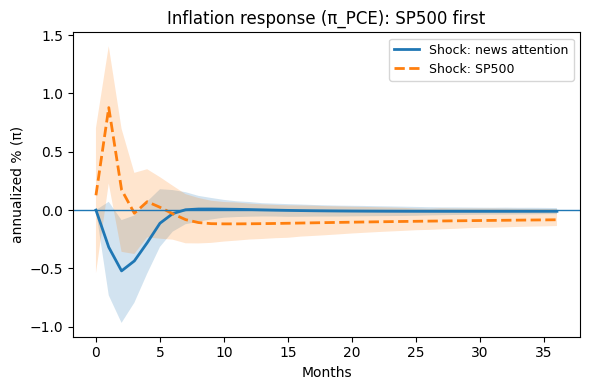

Saved: outputs/IRF_inflation_news_Mexico_vs_sp500_1st.png


In [12]:
print("[2/2] Build VAR dataset and run IRFs (inflation response to both shocks) SP500 FIRST, NEWS LAST ...")

topic_star_attn = (100.0 * theta[topic_star]).rename("news_attn_star")
topic_star_attn = topic_star_attn.reindex(y_raw.index)

# Dataset VAR : ordering = news first + y_t demandé
df_var = pd.concat(
    [topic_star_attn, y_raw], axis=1
).dropna()

ordering = ['logSP500', 'pi_pce', 'logIP', 'FFR'] + ['news_attn_star']  # SP500 first + (pi, logIP, FFR) + news last

# Run 2 IRFs: shock news vs shock SP500, même ordering
specs_inf = {
    "shock_news":  {"df": df_var, "ordering": ordering, "shock": "news_attn_star", "label": "News-attn shock"},
    "shock_sp500": {"df": df_var, "ordering": ordering, "shock": "logSP500",      "label": "SP500 shock"},
}

results_inf = {}

for key, s in specs_inf.items():
    df_use = s["df"][s["ordering"]].dropna()
    print(f"  - {key}: shock={s['shock']} | T={df_use.shape[0]}")
    results_inf[key] = irf.run_var_irf(
        df=df_use,
        ordering=s["ordering"],
        shock_var=s["shock"],
        lags=cfg.LAGS,
        horizon=cfg.IRF_HORIZON,
        reps=cfg.BOOT_REPS,
    )

# Plot: réponse de l'inflation (pi_pce) aux 2 chocs
irf.plot_irf_panel(
    results=results_inf,
    specs=specs_inf,
    out_path=cfg.OUT_DIR / f"IRF_inflation_news_{topic_star}_vs_sp500_1st.png",
    horizon=cfg.IRF_HORIZON,
    resp_var="pi_pce",
    subplots=[
        {
            "title": "Inflation response (π_PCE): SP500 first",
            "series": [
                {"key": "shock_news",  "label": "Shock: news attention", "linestyle": "-",  "linewidth": 2, "with_band": True},
                {"key": "shock_sp500", "label": "Shock: SP500",          "linestyle": "--", "linewidth": 2, "with_band": True},
            ],
        }
    ],
    sharey=True,
    ylabel="annualized % (π)",
)

print("Saved:", cfg.OUT_DIR / f"IRF_inflation_news_{topic_star}_vs_sp500_1st.png")

The response to an news information shock is not changing a lot (almost not at all) when changing the ordering, i.e. the specification of the VAR and hence the identification of the shocks.

### **Robustness check : Group-Lasso VAR selection** on PCE core inflation

In order to check if the selected topics actually move with the underlying components of inflation, we run the same code on PCE core inflation, so excluding food and energy, but not excluding tobacco

#### *1. Loading data*

In [13]:
print("[1/5] Loading theta topics ...")
theta = dl.load_theta(cfg.THETA_FILE)  # index month-start
topic_cols = list(theta.columns)

print("[2/5] Downloading FRED series (INDPRO, FEDFUNDS, PCEPI) ...")
indpro = dl.fred_download_csv(cfg.FRED_SERIES["INDPRO"], cfg.FRED_START, cfg.FRED_END).rename(columns={"INDPRO":"INDPRO"})
ffr    = dl.fred_download_csv(cfg.FRED_SERIES["FEDFUNDS"], cfg.FRED_START, cfg.FRED_END).rename(columns={"FEDFUNDS":"FFR"})
pce_core  = dl.fred_download_csv(cfg.FRED_SERIES["PCEPILFE"], cfg.FRED_START, cfg.FRED_END).rename(columns={"PCEPILFE":"PCE_CORE"})

# Harmonise index en month-start
for d in (indpro, ffr, pce_core):
    d.index = d.index.to_period("M").to_timestamp(how="start")

print("[3/5] Downloading SP500 daily from Stooq + convert to monthly last ...")
sp500_daily = dl.stooq_download_spx_daily(cfg.FRED_START, cfg.FRED_END)   
sp500_m = dl.to_monthly(sp500_daily, how="last")
sp500_m.index = sp500_m.index.to_period("M").to_timestamp(how="start")

# ----- Transformations -----
# logIP_t et logSP500_t (comme dans ton script: 100*log(level))
df_macro = pd.concat([indpro["INDPRO"], ffr["FFR"], pce_core["PCE_CORE"], sp500_m["SP500"]], axis=1).sort_index()

df_macro["logIP"]    = 100.0 * dl.safe_log(df_macro["INDPRO"])
df_macro["logSP500"] = 100.0 * dl.safe_log(df_macro["SP500"])

# inflation PCE headline: pi_t = 1200 * log(P_t/P_{t-1})
df_macro["pi_pce_core"] = 1200.0 * (dl.safe_log(df_macro["PCE_CORE"]) - dl.safe_log(df_macro["PCE_CORE"].shift(1)))
# keep only y vars in requested order
y_raw = df_macro[["pi_pce_core", "logIP", "FFR", "logSP500"]].loc[cfg.FRED_START:cfg.FRED_END].dropna()

print("y_raw head:")
display(y_raw.head())

print("[4/5] Optional: load EPU, VIX/VXO, UMCSENT (comme 5.3 du papier) ...")
# EPU
epu = dl.load_epu_xlsx(cfg.EPU_XLSX_FILE).rename("EPU")
epu = epu.reindex(y_raw.index)

# VIX complété par VXO avant 1990 (même logique que ton script)
vix_daily = dl.fred_download_csv(cfg.FRED_SERIES["VIXCLS"], cfg.FRED_START, cfg.FRED_END)
vix_m = dl.to_monthly(vix_daily, how="last").rename(columns={"VIXCLS":"VIX"})
vix_m.index = vix_m.index.to_period("M").to_timestamp(how="start")

vxo_daily = dl.fred_download_csv(cfg.FRED_SERIES["VXOCLS"], cfg.FRED_START, cfg.FRED_END)
vxo_m = dl.to_monthly(vxo_daily, how="last").rename(columns={"VXOCLS":"VIX"})
vxo_m.index = vxo_m.index.to_period("M").to_timestamp(how="start")

cut = vix_m.index.min()
vix_full = pd.concat([vxo_m.loc[vxo_m.index < cut], vix_m]).sort_index()

# UMCSENT
umcs = dl.fred_download_csv(cfg.FRED_SERIES["UMCSENT"], cfg.FRED_START, cfg.FRED_END).rename(columns={"UMCSENT":"UMCSENT"})
umcs.index = umcs.index.to_period("M").to_timestamp(how="start")

print("[5/5] Build x_all = topics + (EPU, VIX, UMCSENT) ...")
x_topics = 100.0 * theta.copy()               # en %
x_all = pd.concat([x_topics, epu, vix_full["VIX"], umcs["UMCSENT"]], axis=1).dropna()

# Align y/x et impose start pour GL-VAR
joint = pd.concat([y_raw, x_all], axis=1).dropna()
joint = joint.loc[cfg.VAR_GL_START:]
y_all = joint[cfg.Y_ORDER_CORE]
x_all = joint[x_all.columns]

print("Aligned sample:")
print("  y_all:", y_all.shape, y_all.index.min(), "->", y_all.index.max())
print("  x_all:", x_all.shape, x_all.index.min(), "->", x_all.index.max())

[1/5] Loading theta topics ...
[2/5] Downloading FRED series (INDPRO, FEDFUNDS, PCEPI) ...
[3/5] Downloading SP500 daily from Stooq + convert to monthly last ...
y_raw head:


,pi_pce_core,logIP,FFR,logSP500
1984-02-01,7.539770,397.653278,9.59,505.662790
1984-03-01,4.546608,398.141660,9.91,507.003564
1984-04-01,5.634049,398.731599,10.29,507.548627
1984-05-01,2.782101,399.272888,10.32,501.429525
1984-06-01,2.825619,399.638989,11.06,503.161370


[4/5] Optional: load EPU, VIX/VXO, UMCSENT (comme 5.3 du papier) ...
[5/5] Build x_all = topics + (EPU, VIX, UMCSENT) ...
Aligned sample:
  y_all: (378, 4) 1986-01-01 00:00:00 -> 2017-06-01 00:00:00
  x_all: (378, 183) 1986-01-01 00:00:00 -> 2017-06-01 00:00:00


#### *2. Building and running Group-Lasso VAR*

[1/3] Variance-standardize y and x ...
[2/3] Build design matrix for VARX with grouped x-lags ...
  - Lags L=3
  - Samples (T-L)=375
  - #eq K=4  (should be 4)
  - #x vars M=183
  - #regressors P=562 = 1 + L*(K+M)
[3/3] Fit lambda path (Group-Lasso) + compute group norms ...
[0.2        0.19191446 0.18415579 0.17671079 0.16956678 0.16271158
 0.15613352 0.1498214  0.14376446 0.13795239 0.13237529 0.12702366
 0.12188838 0.11696071 0.11223225 0.10769496 0.1033411  0.09916325
 0.09515431 0.09130744 0.08761608 0.08407397 0.08067505 0.07741354
 0.07428388 0.07128076 0.06839904 0.06563382 0.06298039 0.06043424
 0.05799102 0.05564658 0.05339691 0.0512382  0.04916675 0.04717905
 0.04527171 0.04344148 0.04168524 0.04      ]
Lambda high (>=10 survivors): 0.057991 | survivors: 12
Top10 survivors: ['Earnings forecasts', 'Tobacco', 'Small changes', 'Clintons', 'US Senate', 'M&A', 'Major concerns', 'Germany', 'Announce plan', 'Earnings']


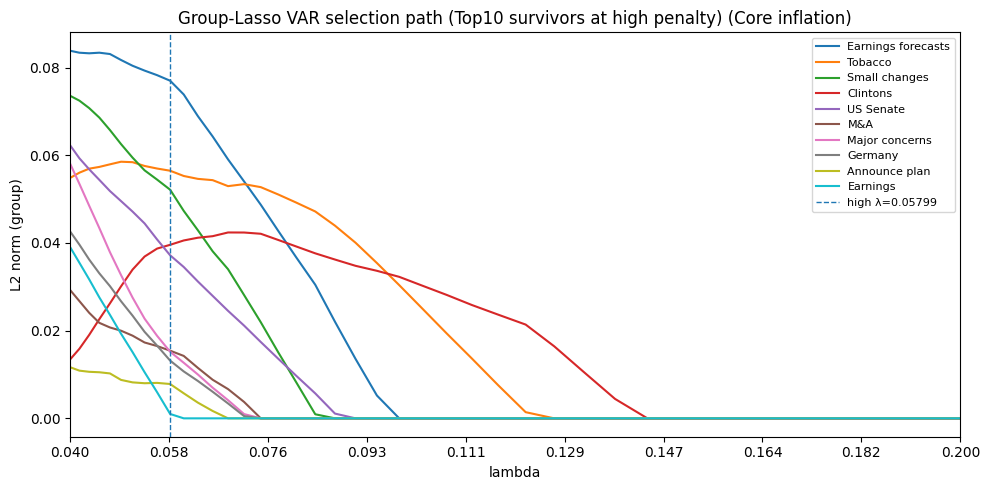

Saved: outputs/CORE_Figure9_like_Top10_L2norms_vs_lambda.png


In [14]:
print("[1/3] Variance-standardize y and x ...")
y_std = gl.variance_standardize(y_all)
x_std = gl.variance_standardize(x_all)

print("[2/3] Build design matrix for VARX with grouped x-lags ...")
Xmat, Ymat, groups, colmeta = gl.build_group_lasso_var_design(y=y_std, x=x_std, lags=cfg.LAGS)
x_vars = list(x_std.columns)
y_vars = list(y_std.columns)
n_groups = int(groups.max()) + 1

print(f"  - Lags L={cfg.LAGS}")
print(f"  - Samples (T-L)={Xmat.shape[0]}")
print(f"  - #eq K={Ymat.shape[1]}  (should be 4)")
print(f"  - #x vars M={len(x_vars)}")
print(f"  - #regressors P={Xmat.shape[1]} = 1 + L*(K+M)")

print("[3/3] Fit lambda path (Group-Lasso) + compute group norms ...")
norms_path = []

print(cfg.LAM_GRID_SCALED)

for lam_scaled in cfg.LAM_GRID_SCALED:
    lam_raw = float(lam_scaled)   # IMPORTANT: pas de *n (comme ta dernière version)

    group_reg = np.full(n_groups, lam_raw, dtype=float)
    group_reg[0] = 0.0  # const + y-lags non pénalisés

    grouplasso = GroupLasso(
                    groups=groups,
                    group_reg=group_reg,
                    l1_reg=0.0,
                    n_iter=cfg.N_ITER_PATH,
                    tol=cfg.TOL_PATH,
                    supress_warning=True,
                    fit_intercept=False,
                    scale_reg="none",
                    warm_start=True,
    )
    grouplasso.fit(Xmat, Ymat)
    coef = grouplasso.coef_.copy()

    norms = gl.group_l2_norms_by_var(coef, colmeta, x_vars)
    norms.name = float(lam_scaled)
    norms_path.append(norms)

norms_df = pd.DataFrame(norms_path).sort_index()
norms_df.index.name = "lambda"
norms_df.to_csv(cfg.OUT_DIR / "CORE_Figure9_norms_path_all_predictors.csv")

# ---- Top-10 survivors à haute pénalisation ----
def active_mask_row(row: pd.Series) -> pd.Series:
    thr = max(cfg.ABS_EPS, cfg.REL_EPS * float(row.max()))
    return row > thr

active_counts = norms_df.apply(lambda r: active_mask_row(r).sum(), axis=1)

if (active_counts >= 10).any():
    lam_high = float(active_counts[active_counts >= 10].index.max())
else:
    lam_high = float(norms_df.index.max())

top10 = norms_df.loc[lam_high].sort_values(ascending=False).head(10).index.tolist()
pd.Series(top10, name="top10_survivors").to_csv(cfg.OUT_DIR / "CORE_Figure9_top10_survivors.csv", index=False)

print(f"Lambda high (>=10 survivors): {lam_high:.6g} | survivors: {int(active_counts.loc[lam_high])}")
print("Top10 survivors:", top10)

# ---- Plot Figure 9-like (Top10 norms vs lambda) ----
plt.figure(figsize=(10, 5))
for v in top10:
    plt.plot(norms_df.index.values, norms_df[v].values, label=v)

plt.xlim(cfg.LAM_LO, cfg.LAM_HI)
xticks = np.linspace(cfg.LAM_LO, cfg.LAM_HI, 10)
plt.xticks(xticks, [f"{x:.3f}" for x in xticks])
plt.axvline(lam_high, linestyle="--", linewidth=1, label=f"high λ={lam_high:.4g}")
plt.xlabel("lambda")
plt.ylabel("L2 norm (group)")
plt.title("Group-Lasso VAR selection path (Top10 survivors at high penalty) (Core inflation)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(cfg.OUT_DIR / "CORE_Figure9_like_Top10_L2norms_vs_lambda.png", dpi=200)
plt.show()
plt.close()

print("Saved:", cfg.OUT_DIR / "CORE_Figure9_like_Top10_L2norms_vs_lambda.png")

In [15]:
topics_wanted = ["Earnings forecasts", "Small changes", "Clintons", "US Senate", "Major concerns"]

rows = []
for topic in topics_wanted:
    if topic not in phi.columns:
        close = closest_topic(topic, phi.columns)
        print(f"[WARN] Topic '{topic}' introuvable. Exemples proches: {close}")
        continue

    s = phi[topic].dropna().sort_values(ascending=False).head(TOPN)

    out = pd.DataFrame(
        {
            "topic": topic,
            "rank": range(1, len(s) + 1),
            "term": s.index.astype(str),     # <-- le terme lui-même
            "weight": s.values,
        }
    )
    rows.append(out)

topwords_df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
display(topwords_df)

# Optionnel: sauvegarde
topwords_df.to_csv(cfg.OUT_DIR / "CORE_top10_terms_phi_selected_topics.csv", index=False)
print("Saved:", cfg.OUT_DIR / "CORE_top10_terms_phi_selected_topics.csv")

,topic,rank,term,weight
0,Earnings forecasts,1,adjust earn,138.984931
1,Earnings forecasts,2,analyst earn,124.072050
2,Earnings forecasts,3,analyst poll,120.086263
3,Earnings forecasts,4,forecast earn,114.125197
4,Earnings forecasts,5,earn forecast,107.906741
5,Earnings forecasts,6,earningspershare,107.017663
6,Earnings forecasts,7,earn expectation,104.328513
7,Earnings forecasts,8,beat expectation,102.152295
8,Earnings forecasts,9,earn guidance,102.099109
9,Earnings forecasts,10,earn estimate,101.596856


Saved: outputs/CORE_top10_terms_phi_selected_topics.csv


#### *3. Cross-validation*

CV RMSE vs lambda ...
lambda_opt = 0.0774135 | min RMSE = 0.471218


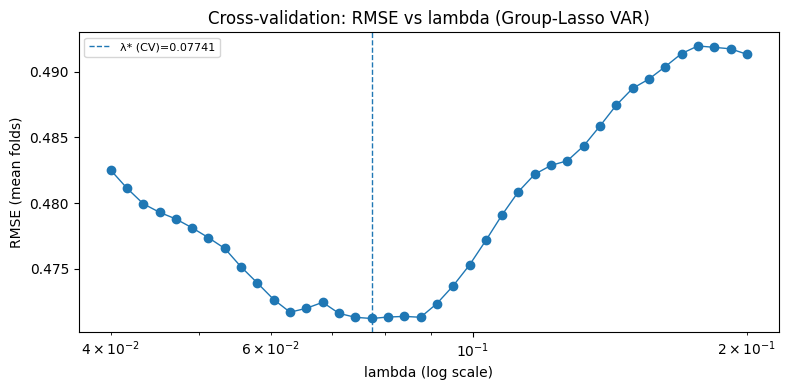

Saved: outputs/CORE_Figure9_CV_RMSE_vs_lambda.png


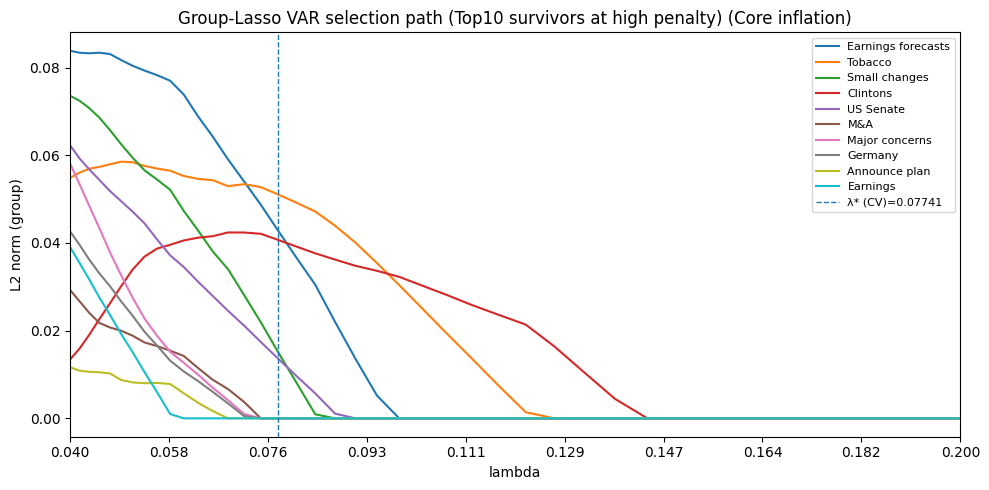

Saved: outputs/CORE_Figure9_like_Top10_L2norms_vs_lambda.png


In [16]:
print("CV RMSE vs lambda ...")
lam_grid = np.array(sorted([float(x) for x in cfg.LAM_GRID_SCALED]))  # ascending for plotting
tscv = TimeSeriesSplit(n_splits=cfg.CV_SPLITS)

rmse_means, rmse_stds = [], []

for lam in lam_grid:
    group_reg = np.full(n_groups, float(lam), dtype=float)
    group_reg[0] = 0.0  # const + y-lags non pénalisés

    fold_rmses = []
    for tr, te in tscv.split(Xmat):
        grouplasso = GroupLasso(
            groups=groups,
            group_reg=group_reg,
            l1_reg=0.0,
            n_iter=cfg.N_ITER_CV,
            tol=cfg.TOL_CV,
            supress_warning=True,
            fit_intercept=False,
            scale_reg="none",
            warm_start=False,
        )
        grouplasso.fit(Xmat[tr], Ymat[tr])
        pred = grouplasso.predict(Xmat[te])

        mse = np.mean((Ymat[te] - pred) ** 2)
        fold_rmses.append(float(np.sqrt(mse)))

    rmse_means.append(float(np.mean(fold_rmses)))
    rmse_stds.append(float(np.std(fold_rmses, ddof=1)) if len(fold_rmses) > 1 else 0.0)

rmse_cv = pd.DataFrame({"lambda": lam_grid, "rmse_mean": rmse_means, "rmse_std": rmse_stds}).set_index("lambda")
rmse_cv.to_csv(cfg.OUT_DIR / "CORE_Figure9_CV_RMSE_vs_lambda.csv")

lam_opt = float(rmse_cv["rmse_mean"].idxmin())
print(f"lambda_opt = {lam_opt:.6g} | min RMSE = {rmse_cv.loc[lam_opt,'rmse_mean']:.6g}")

# Plot RMSE curve
plt.figure(figsize=(8, 4))
plt.plot(rmse_cv.index.values, rmse_cv["rmse_mean"].values, marker="o", linewidth=1)
plt.axvline(lam_opt, linestyle="--", linewidth=1, label=f"λ* (CV)={lam_opt:.4g}")
plt.xscale("log")
plt.xlabel("lambda (log scale)")
plt.ylabel("RMSE (mean folds)")
plt.title("Cross-validation: RMSE vs lambda (Group-Lasso VAR)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(cfg.OUT_DIR / "CORE_Figure9_CV_RMSE_vs_lambda.png", dpi=200)
plt.show()
plt.close()

print("Saved:", cfg.OUT_DIR / "CORE_Figure9_CV_RMSE_vs_lambda.png")

plt.figure(figsize=(10, 5))
for v in top10:
    plt.plot(norms_df.index.values, norms_df[v].values, label=v)

plt.xlim(cfg.LAM_LO, cfg.LAM_HI)
xticks = np.linspace(cfg.LAM_LO, cfg.LAM_HI, 10)
plt.xticks(xticks, [f"{x:.3f}" for x in xticks])
plt.axvline(lam_opt, linestyle="--", linewidth=1, label=f"λ* (CV)={lam_opt:.4g}")
plt.xlabel("lambda")
plt.ylabel("L2 norm (group)")
plt.title("Group-Lasso VAR selection path (Top10 survivors at high penalty) (Core inflation)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(cfg.OUT_DIR / "CORE_Figure9_like_Top10_L2norms_vs_lambda.png", dpi=200)
plt.show()
plt.close()

print("Saved:", cfg.OUT_DIR / "CORE_Figure9_like_Top10_L2norms_vs_lambda.png")

Even in a convex optimization problem (least squares with a group-lasso penalty), the group-wise norms are not guaranteed to be monotone as $\lambda$ increases. The intuition is that when several groups are correlated, increasing $\lambda$ may shrink some “competing” groups to zero, and the model may then reallocate part of the explanatory power to another group that remains active. As a result, the corresponding group norm can temporarily increase before the penalty eventually forces it to decrease.

However, this apparent non-monotonicity can also be caused by numerical artifacts (a common issue with `GroupLasso` combined with `warm\_start` and limited iterations or loose tolerances). In practice, this may show up as oscillations, pronounced “bumps” in the regularization path, or inconsistent paths across repeated runs.

What is really interesting here is that this time the Group Lasso actually selects 4 different topics, and not just one.